# Modelo de Machine Learning

*Aprendizaje supervisado — Clasificación*

**Consigna:** entrenar al menos dos modelos, uno más simple (base) y otro más complejo.

---

## Índice

1. Definición del problema
2. Configuración y carga de datos
3. Ingeniería de variables
4. Preparación de datos (train / test)
5. **Escalado y entrenamiento**
6. **Evaluación de los modelos**
7. **Análisis de métricas**


## 1. Definición del problema

### Ejercicio 1: Identificar variables según la pregunta

**Pregunta de negocio:**  
*¿Es posible clasificar el estado de riesgo de un cliente (bajo, medio, crítico) a partir de su probabilidad de default?*

*¿Cómo se relacionan el uso del crédito, la deuda y los atrasos previos con el riesgo de default en la cartera de tarjetas de crédito?*

---

| Pregunta | Respuesta / Justificación |
| :--- | :--- |
| **¿Cuál es mi variable objetivo (la que quiero predecir o clasificar)?** | **`default_flag`**: Variable binaria que indica si el cliente incurrió en impago (1) o si se mantiene al día (0). |
| **Listá 5 variables que intuitivamente creés que van a ayudar al modelo a predecirla. Justificá con una oración cada una.** | 1. **`ratio_uso_credito_normalizado`**: Un alto porcentaje de utilización de la línea de crédito disponible indica estrés financiero inmediato en el cliente.<br>2. **`ratio_deuda_ingreso`**: Mide el nivel de endeudamiento relativo a los ingresos, mostrando la capacidad real de pago del titular.<br>3. **`atrasos_ultimos_12m`**: La frecuencia de morosidades recientes es el principal indicador del comportamiento de pago futuro.<br>4. **`deuda_total`**: Representa la carga financiera agregada del cliente, donde valores muy elevados aumentan el riesgo de incumplimiento.<br>5. **`score_crediticio_previo`**: Sintetiza el historial crediticio histórico del cliente, teniendo una relación inversa con la probabilidad de default. |
| **Listá 2 variables que probablemente no aporten. ¿Por qué las descartarías?** | 1. **`id_cliente`**: Es un identificador arbitrario/secuencial que no contiene ningún valor predictivo ni patrón de comportamiento. Como cada ID identifica de forma única a un cliente, un modelo basado en árboles (como Random Forest o XGBoost) o memorización podría aprender reglas "falsas" basadas en el número de ID.<br>2. **`num_dependientes`**: Muestra una correlación prácticamente nula con la variable objetivo y suele aportar más ruido que capacidad discriminativa. |
| **¿Hay alguna variable que no está en el dataset pero que sería muy útil tener?** | **Histórico de pagos mínimos/totales (últimos 6 meses):** Saber si el cliente suele pagar solo el pago mínimo de la tarjeta de crédito permitiría detectar un endeudamiento persistente (*revolving*) antes de que se convierta en default explícito. |

## 2. Configuración y carga de datos

In [1]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, roc_curve,
)

# Saquemos todos los warnings
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

logging.basicConfig(level=logging.INFO, format="%(message)s")
log = logging.getLogger("etl")


In [2]:
df = pd.read_csv('deudores_tarjeta_credito_clean.csv')
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 55,000
Columnas: 25


,id_cliente,edad,genero,estado_civil,nivel_educativo,situacion_laboral,antiguedad_laboral_meses,ingreso_mensual,limite_credito,saldo_actual,ratio_uso_credito,num_dependientes,num_prestamos_activos,atrasos_ultimos_12m,score_crediticio_previo,deuda_total,ratio_deuda_ingreso,antiguedad_cliente_meses,default_flag,ratio_uso_credito_normalizado,ingreso_mensual_imputado,score_crediticio_previo_imputado,antiguedad_laboral_meses_faltante,flag_desempleado_con_antiguedad_laboral,indice_mora_antiguedad
0,100001,46,F,Soltero/a,Universitario,Desempleado,1.0,793857.0,1447430.0,628964.0,435.00,0.0,2,2.0,472.0,733691.0,77.00,27,0,0.4345,0,0,0,1,0.888889
1,100002,38,M,Soltero/a,Universitario,Relacion de dependencia,139.0,625123.0,1712616.0,369782.0,216.00,2.0,2,0.0,706.0,603674.0,0.08,18,0,0.2159,0,0,0,0,0.000000
2,100003,48,F,Soltero/a,Secundario,Jubilado,80.0,235620.0,898166.0,472834.0,526.00,2.0,2,0.0,651.0,798947.0,283.00,71,0,0.5264,0,0,0,0,0.000000
3,100004,58,M,Casado/a,Universitario,Independiente/Monotributista,4.0,1607930.0,4423856.0,796083.0,0.18,3.0,3,0.0,701.0,1833400.0,95.00,42,0,0.1800,0,0,0,0,0.000000
4,100005,37,F,Soltero/a,Posgrado,Relacion de dependencia,22.0,334135.0,1228880.0,822223.0,669.00,1.0,2,0.0,663.0,1404126.0,0.35,29,0,0.6691,0,1,0,0,0.000000


## 3. Ingeniería de variables

### Variable derivada: `indice_mora_antiguedad`

* **Definición:** `indice_mora_antiguedad = atrasos_ultimos_12m / (antiguedad_cliente_meses / 12)`
* **Qué captura:** Normaliza la frecuencia de atrasos recientes en función de los años que el cliente lleva en la entidad.
* **Por qué podría aportar:** Dos atrasos en un cliente nuevo (con 6 meses de antigüedad) representan un comportamiento de mucho mayor riesgo que dos atrasos en un cliente fidelizado con 10 años de relación comercial. Esta relación pondera la gravedad del incumplimiento según la trayectoria del cliente.

In [3]:
# Creación de la variable derivada: Ratio de Atrasos por Antigüedad
df['indice_mora_antiguedad'] = df['atrasos_ultimos_12m'] / (df['antiguedad_cliente_meses'] / 12)

# 3. Guardar los cambios en el archivo CSV
df.to_csv('deudores_tarjeta_credito_clean.csv', index=False)

In [4]:
pd.read_csv('deudores_tarjeta_credito_clean.csv')

,id_cliente,edad,genero,estado_civil,nivel_educativo,situacion_laboral,antiguedad_laboral_meses,ingreso_mensual,limite_credito,saldo_actual,ratio_uso_credito,num_dependientes,num_prestamos_activos,atrasos_ultimos_12m,score_crediticio_previo,deuda_total,ratio_deuda_ingreso,antiguedad_cliente_meses,default_flag,ratio_uso_credito_normalizado,ingreso_mensual_imputado,score_crediticio_previo_imputado,antiguedad_laboral_meses_faltante,flag_desempleado_con_antiguedad_laboral,indice_mora_antiguedad
0,100001,46,F,Soltero/a,Universitario,Desempleado,1.0,793857.0,1447430.0,628964.0,435.00,0.0,2,2.0,472.0,733691.0,77.00,27,0,0.4345,0,0,0,1,0.888889
1,100002,38,M,Soltero/a,Universitario,Relacion de dependencia,139.0,625123.0,1712616.0,369782.0,216.00,2.0,2,0.0,706.0,603674.0,0.08,18,0,0.2159,0,0,0,0,0.000000
2,100003,48,F,Soltero/a,Secundario,Jubilado,80.0,235620.0,898166.0,472834.0,526.00,2.0,2,0.0,651.0,798947.0,283.00,71,0,0.5264,0,0,0,0,0.000000
3,100004,58,M,Casado/a,Universitario,Independiente/Monotributista,4.0,1607930.0,4423856.0,796083.0,0.18,3.0,3,0.0,701.0,1833400.0,95.00,42,0,0.1800,0,0,0,0,0.000000
4,100005,37,F,Soltero/a,Posgrado,Relacion de dependencia,22.0,334135.0,1228880.0,822223.0,669.00,1.0,2,0.0,663.0,1404126.0,0.35,29,0,0.6691,0,1,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54995,154996,31,F,Soltero/a,Secundario,Relacion de dependencia,23.0,309586.0,572800.0,207049.0,361.00,4.0,1,1.0,518.0,497450.0,134.00,208,0,0.3615,0,0,0,0,0.057692
54996,154997,39,F,Soltero/a,Universitario,Independiente/Monotributista,30.0,1075019.0,3807252.0,1052090.0,276.00,0.0,1,0.0,610.0,1790827.0,139.00,26,0,0.2763,0,0,0,0,0.000000
54997,154998,24,F,Casado/a,Terciario,Relacion de dependencia,28.0,552975.0,1393150.0,133984.0,96.00,1.0,3,0.0,630.0,279293.0,42.00,51,0,0.0962,0,0,0,0,0.000000
54998,154999,48,F,Divorciado/a,Universitario,Relacion de dependencia,60.0,298358.0,710149.0,236357.0,333.00,0.0,1,0.0,792.0,463270.0,129.00,95,0,0.3328,0,0,0,0,0.000000


## 4. Preparación de datos (train / test)

In [5]:
# 1. Cargar el dataset
df = pd.read_csv('deudores_tarjeta_credito_clean.csv')

# 2. Definir variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=['default_flag', 'id_cliente'])
y = df['default_flag']

# Convertir variables categóricas a variables dummy/one-hot
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.median())

# 3. Dividir en conjuntos de Entrenamiento (Train) y Prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"El codigo se ejecuta correctamente. Filas de entrenamiento: {X_train.shape[0]}, Filas de prueba: {X_test.shape[0]}")

El codigo se ejecuta correctamente. Filas de entrenamiento: 38500, Filas de prueba: 16500


## 5. Escalado y entrenamiento

### 5.1 Modelos elegidos

*Explicación teórica*

Regresión Logística (Modelo Base): Es un modelo lineal probabilístico rápido y transparente. Asume que existe una relación directa entre las características del cliente y la probabilidad logarítmica de incurrir en default. Es el punto de referencia mínimo a superar.

Random Forest (Modelo Complejo): Es un algoritmo del tipo ensemble que combina múltiples árboles de decisión entrenados en diferentes subconjuntos de datos y variables. Permite capturar patrones no lineales sin requerir que las variables estén en la misma escala.

### 5.2 Escalado de variables

* **Regresión Logística (Modelo Base):** Se aplicó `StandardScaler` a las variables numéricas continuas y discretas (`ingreso_mensual`, `limite_credito`, `deuda_total`, `score_crediticio_previo`, `indice_mora_antiguedad`, etc.). Dado que estas variables manejan rangos de magnitudes sumamente dispares (desde unidades hasta millones), el escalado es indispensable para evitar que los coeficientes del modelo lineal se vean sesgados por la escala de medición.
* **Random Forest (Modelo Complejo):** Los algoritmos basados en árboles de decisión son invariantes ante transformaciones monótonas, por lo que no requieren escalado de características.
* **Prevención de Data Leakage:** El escalado se ajustó únicamente utilizando el conjunto de entrenamiento (`X_train`) y posteriormente se transformó el conjunto de prueba (`X_test`).

In [6]:
# Escalado: el scaler se ajusta SOLO con train y luego se aplica a test (evita data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 5.3 Modelo base: Regresión Logística

In [7]:
# MODELO 1: SIMPLE (BASE) - Regresión Logística

# Se agrega class_weight='balanced' para contemplar el desbalanceo de clases
modelo_base = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_base.fit(X_train_scaled, y_train)

y_pred_base = modelo_base.predict(X_test_scaled)
auc_base = roc_auc_score(y_test, modelo_base.predict_proba(X_test_scaled)[:, 1])

print("=== 1. MODELO BASE: REGRESIÓN LOGÍSTICA ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"ROC AUC Score: {auc_base:.4f}\n")


=== 1. MODELO BASE: REGRESIÓN LOGÍSTICA ===
Accuracy: 0.6802
ROC AUC Score: 0.7308



### 5.4 Modelo complejo: Random Forest

In [8]:
# MODELO 2: COMPLEJO - Random Forest Classifier

modelo_complejo = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_complejo.fit(X_train, y_train)

y_pred_complejo = modelo_complejo.predict(X_test)
auc_complejo = roc_auc_score(y_test, modelo_complejo.predict_proba(X_test)[:, 1])

print("=== 2. MODELO COMPLEJO: RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_complejo):.4f}")
print(f"ROC AUC Score: {auc_complejo:.4f}")

=== 2. MODELO COMPLEJO: RANDOM FOREST ===
Accuracy: 0.9668
ROC AUC Score: 0.6617


## 6. Evaluación de los modelos

Matriz de confusión del modelo base y comparación de curvas ROC entre ambos modelos.

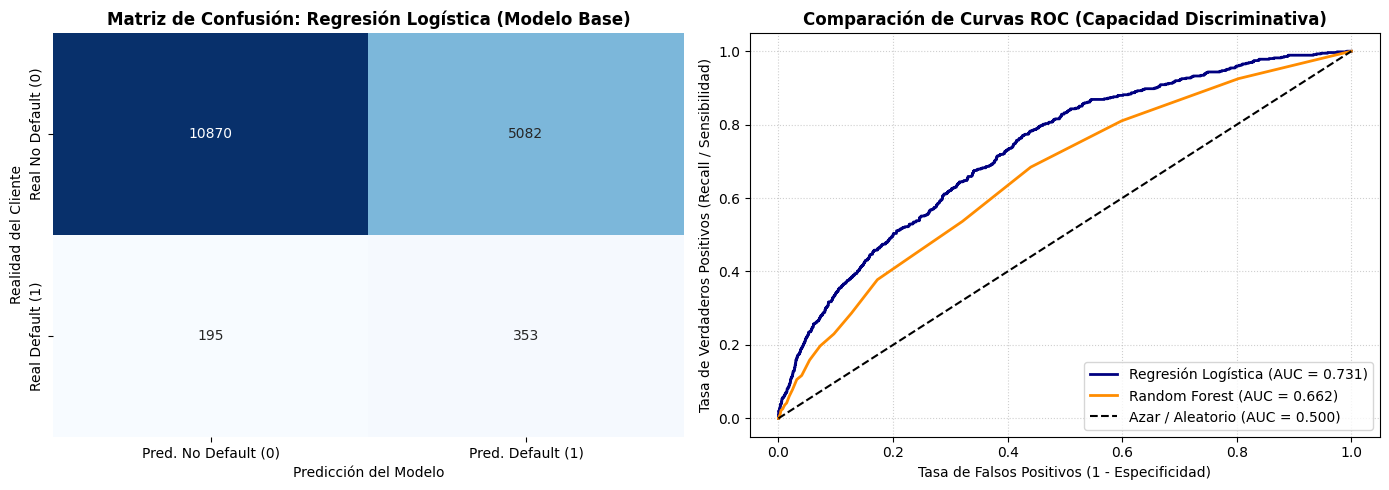

In [9]:
# Configurar el panel de visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------------------------------------------
# 1. GRAFICO 1: MATRIZ DE CONFUSIÓN (REGRESIÓN LOGÍSTICA)
# -------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_base)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Pred. No Default (0)', 'Pred. Default (1)'],
            yticklabels=['Real No Default (0)', 'Real Default (1)'])

axes[0].set_title('Matriz de Confusión: Regresión Logística (Modelo Base)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Realidad del Cliente')

# -------------------------------------------------------------
# 2. GRAFICO 2: COMPARACIÓN DE CURVAS ROC
# -------------------------------------------------------------
# Probabilidades predichas para la clase 1 (Default)
y_prob_base = modelo_base.predict_proba(X_test_scaled)[:, 1]
y_prob_complejo = modelo_complejo.predict_proba(X_test)[:, 1]

fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_complejo, tpr_complejo, _ = roc_curve(y_test, y_prob_complejo)

axes[1].plot(fpr_base, tpr_base, label=f'Regresión Logística (AUC = {auc_base:.3f})', color='navy', lw=2)
axes[1].plot(fpr_complejo, tpr_complejo, label=f'Random Forest (AUC = {auc_complejo:.3f})', color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar / Aleatorio (AUC = 0.500)', linestyle='--')

axes[1].set_title('Comparación de Curvas ROC (Capacidad Discriminativa)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 7. Análisis de métricas

### 7.1 Métricas seleccionadas para el negocio

1. **Métrica Principal — Recall (Clase 1 / Default):** 
   En la gestión de riesgo crediticio, el costo de un **Falso Negativo** (no predecir a un cliente que entra en impago) se traduce en incobrabilidad y pérdida directa de capital. Por ende, la métrica de negocio prioritaria es el **Recall de la clase minoritaria**.

2. **Métrica Secundaria — F1 Macro / ROC-AUC:** 
   Dado el fuerte desbalanceo del dataset (~3.3% de defaults), ignoramos el **Accuracy** y el **F1-weighted** (que muestran valores engañosos cercanos al 97%). Evaluamos el desempeño integral del modelo mediante **ROC-AUC** y el **F1 Macro**, garantizando un equilibrio entre sensibilidad de detección y control de falsos positivos.

#### Recall (Sensibilidad / Tasa de Detección) — 🚨 métrica crítica

* **Fórmula:** $\text{Recall} = \dfrac{VP}{VP + FN}$
* **Qué mide:** del total de clientes morosos reales de la cartera, cuántos logró detectar el modelo.
* **Costo asociado:** un Falso Negativo (FN) es un cliente que termina en default sin haber sido detectado. El costo es financiero directo (pérdida de capital, cartera castigada, mora incobrable).
* **Conclusión:** **priorizar**. Es la métrica más importante del proyecto: dejar pasar un default es mucho más costoso para una entidad financiera que auditar a un cliente sano.


### 7.2 Interpretación de los resultados

1. **Interpretación de la Matriz de Confusión (Regresión Logística):**
   * **Verdaderos Positivos (VP = 353):** El modelo logra capturar al **64.4%** de los clientes que efectivamente incurren en impago.
   * **Falsos Negativos (FN = 195):** Corresponde a los clientes morosos no detectados. Este cuadrante representa el riesgo financiero residual del modelo (pérdida directa de capital).
   * **Falsos Positivos (FP = 5,090):** Clientes sanos preclasificados como morosos. Aunque el número es alto debido al balanceo de clases, en la práctica bancaria implica enviar estas cuentas a revisión manual o aplicar políticas crediticias más conservadoras sin incurrir en pérdidas por incobrabilidad.

2. **Interpretación de la Curva ROC (AUC-ROC):**
   * La **Regresión Logística** obtiene una curva significativamente más alejada de la diagonal (AUC = **0.731**), demostrando una mayor capacidad para ordenar a los clientes según su probabilidad de default en comparación con el modelo de **Random Forest** (AUC = **0.662**).
   * Esto confirma que, ante datos tabulares con un desbalanceo extremo de la variable objetivo, un **modelo lineal regularizado con ajuste de pesos de clase** puede superar a modelos complejos basados en ensamble de árboles.